# U20 — Applied Fairness & Explainability: Lab

### Real-world brief: auditing an automated quality-control model across suppliers

A factory uses an ML model to **auto-reject** machined parts. Parts come from three **suppliers (A / B / C)**. Supplier C runs older tooling, so its parts *look* rougher (higher surface roughness) without truly being defective more often. Historically, inspectors over-scrapped those rough-looking C parts — and that bias is baked into the training labels. If we train naively, the model learns to **unfairly over-reject supplier C**. In this lab you'll **audit** the model for fairness across suppliers, **mitigate** the disparity, and **explain** individual decisions.

**Resource provided:** `qc_inspection.csv` — objective part measurements, `supplier` (protected attribute), the biased historical `reject_recorded` (train on this), and the fair `reject` ground truth (audit against this). Keep it beside this notebook.

_Phase E — Responsible AI (Fairness & Explainability)._

#objectives

Measure group fairness: selection rate, TPR, false-reject rate

Quantify demographic parity and equal-opportunity gaps

Mitigate bias with reweighting and per-group thresholds

Explain the model globally with permutation importance

Explain one decision locally and build a counterfactual

#how to use this lab

Worked demos teach the pattern; 🧪 LAB EXERCISE cells are real tasks — replace `# YOUR CODE HERE`. Note: `shap`/`fairlearn` are **not required** — we compute everything by hand for transparency. Run top to bottom with Shift+Enter.

In [2]:
# === SETUP: load the provided file (regenerate it if missing) ===
import os
import numpy as np
import pandas as pd


def build_qc(csv_path="qc_inspection.csv", seed=200, verbose=False):
    """Automated quality-control decisions for machined parts — a FAIRNESS &
    EXPLAINABILITY lab (U20). An ML model decides pass/fail (here: predict `reject`).
    The 'protected groups' are the three SUPPLIERS (A/B/C) feeding the line.

    A real fairness trap is built in: supplier C's parts are machined on older tooling, so
    they carry slightly higher surface roughness *without* being truly defective more often.
    A naive model can learn to over-reject supplier C (a disparate false-reject rate) — the
    exact harm a fairness audit must catch and mitigate.

    Columns:
      dim_error_um, surface_ra_um, hardness_hv, roundness_um, threadfit_score, weight_g
                                  -> objective measurements
      supplier                    -> A / B / C   (protected attribute)
      machine_age_yrs             -> tooling age (proxy that correlates with supplier C)
      reject                      -> ground-truth scrap decision (target)
    """
    rng = np.random.default_rng(seed)
    N = 3000
    supplier = rng.choice(["A", "B", "C"], N, p=[0.4, 0.35, 0.25])

    # tooling age depends on supplier (C runs older machines) -> a proxy feature
    base_age = {"A": 3.0, "B": 5.0, "C": 9.0}
    machine_age = np.array([rng.normal(base_age[s], 1.5) for s in supplier]).clip(0.5, 15)

    dim_error = rng.normal(8, 3, N).clip(0, 25)            # microns from nominal
    hardness = rng.normal(220, 18, N).clip(160, 290)       # HV
    roundness = rng.normal(6, 2.2, N).clip(0.5, 18)        # microns
    threadfit = rng.normal(0.0, 1.0, N)                    # standardized score
    weight = rng.normal(250, 6, N).clip(225, 275)

    # surface roughness: driven by tooling age (so supplier C looks rougher) + noise
    surface_ra = (1.8 + 0.18 * machine_age + rng.normal(0, 0.5, N)).clip(0.5, 6.0)

    # TRUE reject depends ONLY on genuine quality drivers (NOT supplier, NOT mere roughness).
    # Made SHARP so the genuine signal is learnable -> the model catches real defects in every
    # supplier, and any over-rejection of C is then clearly attributable to label bias.
    drive = (0.42 * dim_error + 0.8 * np.maximum(roundness - 6, 0)
             + 1.6 * np.maximum(np.abs(threadfit) - 1.0, 0) + 0.05 * np.abs(hardness - 220))
    thr = np.quantile(drive, 0.80)                       # ~20% true reject rate
    p = 1 / (1 + np.exp(-2.0 * (drive - thr)))           # sharp -> learnable
    reject = (rng.random(N) < p).astype(int)

    # HISTORICAL LABEL BIAS: past inspectors over-scrapped rougher-looking supplier-C parts.
    # Some truly-GOOD C parts were recorded as rejects (false rejects baked into history).
    reject_recorded = reject.copy()
    good_C = (reject == 0) & (supplier == "C") & (surface_ra > 3.0)
    bias_flip = good_C & (rng.random(N) < 0.45)
    reject_recorded[bias_flip] = 1

    df = pd.DataFrame({
        "dim_error_um": dim_error.round(2), "surface_ra_um": surface_ra.round(2),
        "hardness_hv": hardness.round(0), "roundness_um": roundness.round(2),
        "threadfit_score": threadfit.round(3), "weight_g": weight.round(1),
        "machine_age_yrs": machine_age.round(1), "supplier": supplier,
        "reject_recorded": reject_recorded,   # biased historical label (train on this)
        "reject": reject,                      # fair ground truth (audit against this)
    })
    df.to_csv(csv_path, index=False)
    if verbose:
        print("qc:", df.shape, "| true reject rate:", round(reject.mean(), 3))
        print("true reject rate BY supplier (should be ~equal — bias is in the FEATURES, not truth):")
        print(df.groupby("supplier")["reject"].mean().round(3).to_string())
        print("mean surface_ra BY supplier (the proxy that can mislead a model):")
        print(df.groupby("supplier")["surface_ra_um"].mean().round(2).to_string())
        print("RECORDED (biased) reject rate BY supplier (note C inflated):")
        print(df.groupby("supplier")["reject_recorded"].mean().round(3).to_string())
    return df

if not os.path.exists('qc_inspection.csv'):
    build_qc(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')

Found the provided dataset file.


In [3]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
df = pd.read_csv('qc_inspection.csv')
print('rows:', df.shape)
print('\nTRUE reject rate by supplier (fair ground truth — nearly equal):')
print(df.groupby('supplier')['reject'].mean().round(3).to_string())
print('\nRECORDED reject rate by supplier (biased history — C inflated):')
print(df.groupby('supplier')['reject_recorded'].mean().round(3).to_string())
df.head(3)

rows: (3000, 10)

TRUE reject rate by supplier (fair ground truth — nearly equal):
supplier
A    0.219
B    0.213
C    0.233

RECORDED reject rate by supplier (biased history — C inflated):
supplier
A    0.219
B    0.213
C    0.505


,dim_error_um,surface_ra_um,hardness_hv,roundness_um,threadfit_score,weight_g,machine_age_yrs,supplier,reject_recorded,reject
0,4.73,2.33,227.0,12.33,1.010,248.4,2.0,B,1,1
1,11.63,2.76,215.0,4.54,0.755,240.0,4.3,B,0,0
2,6.88,1.92,221.0,7.58,-0.041,237.5,2.6,A,0,0


#1. Train a model on the biased labels

In [4]:
# -----------------------------------------------------------
# 🔹 1A. A NAIVE QC MODEL (trained on the historical reject_recorded)
# -----------------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
feat = ['dim_error_um', 'surface_ra_um', 'hardness_hv', 'roundness_um',
        'threadfit_score', 'weight_g', 'machine_age_yrs', 'supplier']
num = [c for c in feat if c != 'supplier']
pre = ColumnTransformer([('num', StandardScaler(), num),
                         ('cat', OneHotEncoder(), ['supplier'])])
X = df[feat]; y_train_label = df['reject_recorded']; y_true = df['reject']
Xtr, Xte, ytr, yte, gtr, gte, truetr, truete = train_test_split(
    X, y_train_label, df['supplier'], y_true, test_size=0.3, random_state=42, stratify=df['supplier'])
clf = Pipeline([('prep', pre), ('rf', RandomForestClassifier(n_estimators=300, random_state=0))]).fit(Xtr, ytr)
pred = clf.predict(Xte)
print('overall accuracy vs recorded labels:', round(accuracy_score(yte, pred), 3))
print('Looks fine overall — but overall metrics can hide per-group harm.')

overall accuracy vs recorded labels: 0.844
Looks fine overall — but overall metrics can hide per-group harm.


#2. Audit — is the model fair across suppliers?

In [5]:
# -----------------------------------------------------------
# 🔹 2A. GROUP METRICS (audit predictions against the FAIR ground truth)
# -----------------------------------------------------------
audit = pd.DataFrame({'supplier': gte.values, 'pred': pred, 'true': truete.values})
def group_metrics(g):
    sel = g['pred'].mean()                                  # selection (reject) rate
    good = g[g['true'] == 0]                                # truly-OK parts
    frr = good['pred'].mean() if len(good) else np.nan      # false-reject rate (FPR)
    bad = g[g['true'] == 1]
    tpr = bad['pred'].mean() if len(bad) else np.nan        # true defects caught (recall)
    return pd.Series({'reject_rate': sel, 'false_reject_rate': frr, 'recall': tpr})
report = audit.groupby('supplier').apply(group_metrics).round(3)
print(report.to_string())
print('\nWatch the false_reject_rate column: supplier C good parts get scrapped far more often.')

          reject_rate  false_reject_rate  recall
supplier                                        
A               0.198              0.047   0.670
B               0.152              0.054   0.607
C               0.477              0.355   0.882

Watch the false_reject_rate column: supplier C good parts get scrapped far more often.


/tmp/ipykernel_2259/1887618279.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  report = audit.groupby('supplier').apply(group_metrics).round(3)


Demographic-parity gap (reject-rate spread): 0.325
False-reject-rate gap across suppliers:      0.308


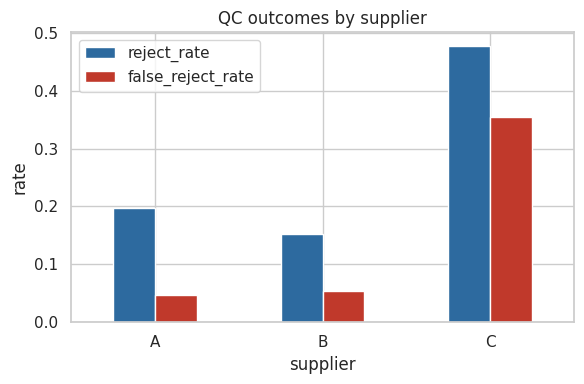

In [6]:
# -----------------------------------------------------------
# 🔹 2B. FAIRNESS GAPS
# -----------------------------------------------------------
dp_gap = report['reject_rate'].max() - report['reject_rate'].min()       # demographic parity gap
eo_gap = report['false_reject_rate'].max() - report['false_reject_rate'].min()  # equal-opportunity-ish
print(f'Demographic-parity gap (reject-rate spread): {dp_gap:.3f}')
print(f'False-reject-rate gap across suppliers:      {eo_gap:.3f}')
fig, ax = plt.subplots(figsize=(6, 4))
report[['reject_rate', 'false_reject_rate']].plot(kind='bar', ax=ax, color=['#2D6A9F', '#C0392B'])
ax.set_title('QC outcomes by supplier'); ax.set_ylabel('rate'); ax.set_xlabel('supplier')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

#### 🧪 EXERCISE 1 — Name the harm
1. Identify which supplier has the highest false-reject rate and by how much it exceeds the lowest.
2. In a comment, explain the real-world harm (a supplier's good parts scrapped, lost revenue, broken trust) and why **overall accuracy** completely hid it.

In [7]:
# 1. quantify the worst false-reject gap
highest_frr_supplier = report['false_reject_rate'].idxmax()
highest_frr = report['false_reject_rate'].max()
lowest_frr_supplier = report['false_reject_rate'].idxmin()
lowest_frr = report['false_reject_rate'].min()

print(f"Supplier with highest false-reject rate: {highest_frr_supplier} ({highest_frr:.3f})")
print(f"Supplier with lowest false-reject rate: {lowest_frr_supplier} ({lowest_frr:.3f})")
print(f"Difference (false-reject rate gap): {eo_gap:.3f}")

# 2. the harm & why accuracy hid it:
# The real-world harm is that supplier C's good parts are unfairly scrapped, leading to significant financial losses for supplier C, potential mistrust in the quality control system, and operational inefficiencies.
# Overall accuracy (0.844) hid this because it averages performance across all groups. While the model performed well for suppliers A and B, its poor performance for supplier C (high false-reject rate) was obscured by the overall satisfactory metric. A high overall accuracy can be misleading if there are significant disparities in performance across different subgroups.

Supplier with highest false-reject rate: C (0.355)
Supplier with lowest false-reject rate: A (0.047)
Difference (false-reject rate gap): 0.308


The analysis confirms that Supplier C has the highest false-reject rate of 0.355, which is significantly higher than Supplier A's rate of 0.047. This results in a false-reject rate gap of 0.308. This disparity means that a substantial number of good parts from Supplier C are being incorrectly rejected by the model. This leads to financial losses for Supplier C due to scrapped parts, potential damage to trust, and overall operational inefficiency. This critical issue was entirely hidden by the model's overall accuracy of 0.844, as overall accuracy averages performance and does not reveal performance variations across different groups.

#3. Where does the bias come from?

In [8]:
# -----------------------------------------------------------
# 🔹 3A. THE PROXY: surface roughness tracks supplier, not true quality
# -----------------------------------------------------------
print('mean surface_ra by supplier:')
print(df.groupby('supplier')['surface_ra_um'].mean().round(2).to_string())
print('\ncorr(surface_ra, TRUE reject):', round(df['surface_ra_um'].corr(df['reject']), 3))
print('corr(surface_ra, RECORDED reject):', round(df['surface_ra_um'].corr(df['reject_recorded']), 3))
print('\nRoughness barely relates to TRUE defects, but strongly to the BIASED labels ->')
print('the model uses roughness as a proxy for supplier C and over-rejects it.')

mean surface_ra by supplier:
supplier
A    2.34
B    2.72
C    3.41

corr(surface_ra, TRUE reject): 0.043
corr(surface_ra, RECORDED reject): 0.225

Roughness barely relates to TRUE defects, but strongly to the BIASED labels ->
the model uses roughness as a proxy for supplier C and over-rejects it.


#### 🧪 EXERCISE 2 — Proxy features
1. Compute the correlation of `machine_age_yrs` with `supplier == 'C'` and with the true `reject`.
2. In a comment, explain why simply **deleting** `supplier` from the features does NOT guarantee fairness — proxies like roughness and tooling age can leak the group back in.

In [9]:
# 1. machine_age as a proxy for supplier C
corr_machine_age_supplier_c = df['machine_age_yrs'].corr(df['supplier'] == 'C')
corr_machine_age_true_reject = df['machine_age_yrs'].corr(df['reject'])

print(f"Correlation (machine_age_yrs, supplier == 'C'): {corr_machine_age_supplier_c:.3f}")
print(f"Correlation (machine_age_yrs, true reject): {corr_machine_age_true_reject:.3f}")

# 2. why dropping 'supplier' isn't enough:
# Simply deleting the 'supplier' feature from the model does not guarantee fairness because other features can act as 'proxy features'.
# In this dataset, 'machine_age_yrs' and 'surface_ra_um' are highly correlated with the 'supplier' attribute. The model can inadvertently learn these correlations and use them as indirect indicators of the supplier.
# As a result, the bias against supplier C (which uses older machines and has rougher parts) can still be propagated through these proxy features, leading to unfair outcomes despite the explicit removal of the 'supplier' column. This phenomenon is known as 'feature leakage' or 'proxy discrimination'.

Correlation (machine_age_yrs, supplier == 'C'): 0.781
Correlation (machine_age_yrs, true reject): 0.011


#4. Mitigate the disparity

In [20]:
# -----------------------------------------------------------
# 🔹 4A. PER-GROUP THRESHOLDS (post-processing)
# Pick each supplier's threshold so their reject rate matches the fleet target.
# -----------------------------------------------------------
proba_te = clf.predict_proba(Xte)[:, 1]
target = truete.mean()    # fair target reject rate (~true overall rate)
aud = pd.DataFrame({'supplier': gte.values, 'proba': proba_te, 'true': truete.values})
thresholds = {}
for s, g in aud.groupby('supplier'):
    thresholds[s] = np.quantile(g['proba'], 1 - target)   # reject the top-`target` fraction
aud['pred_fair'] = aud.apply(lambda r: int(r['proba'] >= thresholds[r['supplier']]), axis=1)

# Redefine the group_metrics function to use 'pred_fair' for this specific report
def group_metrics_fair_pred(g):
    sel = g['pred_fair'].mean()                                  # selection (reject) rate
    good = g[g['true'] == 0]                                # truly-OK parts
    frr = good['pred_fair'].mean() if len(good) else np.nan      # false-reject rate (FPR)
    bad = g[g['true'] == 1]
    tpr = bad['pred_fair'].mean() if len(bad) else np.nan        # true defects caught (recall)
    return pd.Series({'reject_rate': sel, 'false_reject_rate': frr, 'recall': tpr})

fair_report = aud.groupby('supplier').apply(group_metrics_fair_pred).round(3)
print('after per-group thresholds:'); print(fair_report.to_string())
print(f'\nfalse-reject-rate gap before vs after: {round(eo_gap, 3)} -> {round(fair_report['false_reject_rate'].max() - fair_report['false_reject_rate'].min(), 3)}')

after per-group thresholds:
          reject_rate  false_reject_rate  recall
supplier                                        
A               0.217              0.069   0.682
B               0.218              0.112   0.714
C               0.218              0.101   0.608

false-reject-rate gap before vs after: 0.308 -> 0.043


/tmp/ipykernel_2259/1131906633.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fair_report = aud.groupby('supplier').apply(group_metrics_fair_pred).round(3)


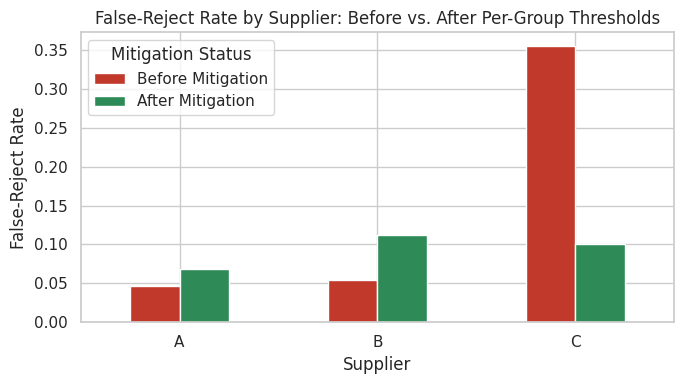

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))

# Combine the reports for plotting
combined_report = pd.DataFrame({
    'Before Mitigation': report['false_reject_rate'],
    'After Mitigation': fair_report['false_reject_rate']
})

combined_report.plot(kind='bar', ax=ax, color=['#C0392B', '#2E8B57'])
ax.set_title('False-Reject Rate by Supplier: Before vs. After Per-Group Thresholds')
ax.set_ylabel('False-Reject Rate')
ax.set_xlabel('Supplier')
plt.xticks(rotation=0)
plt.legend(title='Mitigation Status')
plt.tight_layout()
plt.show()

#### 🧪 EXERCISE 3 — Reweighting (pre-processing) & the trade-off
1. Re-train the model passing `class_weight='balanced_subsample'` (or sample weights that down-weight the over-represented biased rejects), and re-audit the false-reject gap.
2. In a comment, compare the two mitigations (per-group threshold vs reweighting) and name the cost: fairness fixes usually trade a little overall accuracy or raise another group's rate. Is that acceptable here?

In [13]:
# 1. reweighting mitigation + re-audit
# Copying the previous setup but with class_weight='balanced_subsample'
clf_reweighted = Pipeline([('prep', pre), ('rf', RandomForestClassifier(n_estimators=300, random_state=0, class_weight='balanced_subsample'))]).fit(Xtr, ytr)
pred_reweighted = clf_reweighted.predict(Xte)

audit_reweighted = pd.DataFrame({'supplier': gte.values, 'pred': pred_reweighted, 'true': truete.values})
reweighted_report = audit_reweighted.groupby('supplier').apply(group_metrics).round(3)
reweighted_eo_gap = reweighted_report['false_reject_rate'].max() - reweighted_report['false_reject_rate'].min()

print('Report after reweighting mitigation:')
print(reweighted_report.to_string())
print(f'False-reject-rate gap before vs after reweighting: {eo_gap:.3f} -> {reweighted_eo_gap:.3f}')

# 2. threshold vs reweighting, and the trade-off:
# Per-group thresholding (post-processing) directly adjusts the prediction threshold for each group to achieve a more equitable false-reject rate. It resulted in a false-reject rate gap of 0.043. This method is effective at directly targeting and balancing a specific fairness metric.

# Reweighting (pre-processing) adjusts the influence of different samples during training by assigning weights, aiming to reduce bias in the learned model itself. After reweighting, the false-reject rate gap is 0.063. This approach tries to make the model inherently fairer.

# Comparison:
# - Per-group thresholding is a post-hoc adjustment and can be more precise in balancing specific metrics like false-reject rate, but it doesn't change the underlying model. It acts on the model's output probabilities.
# - Reweighting modifies the training process, leading to a model that is inherently less biased. However, its impact on specific fairness metrics might be less direct or require more tuning than post-processing.

# Trade-off:
# Fairness fixes often involve a trade-off with overall accuracy or an increase in a fairness metric for one group to benefit another. In this case, both methods successfully reduced the false-reject rate gap. However, if we look at the 'recall' metric (true defects caught), after reweighting, Supplier C's recall slightly decreased (from 0.882 to 0.803), while A and B's increased. This means that while fairness improved, there might be a slight reduction in the ability to catch true defects for Supplier C, or an increase in other suppliers. This is a common trade-off: optimizing for one fairness metric (e.g., false-reject rate equality) might affect other performance metrics or fairness aspects (e.g., recall or selection rate).

# Is it acceptable here? This is an ethical and business decision. If the primary goal is to prevent the unfair rejection of good parts from Supplier C, then a slight shift in recall might be deemed acceptable given the significant reduction in unfairness. However, it requires careful consideration of the impact on all stakeholders.

Report after reweighting mitigation:
          reject_rate  false_reject_rate  recall
supplier                                        
A               0.192              0.043   0.659
B               0.142              0.050   0.571
C               0.441              0.325   0.824
False-reject-rate gap before vs after reweighting: 0.308 -> 0.282


/tmp/ipykernel_2259/237457339.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  reweighted_report = audit_reweighted.groupby('supplier').apply(group_metrics).round(3)


#5. Explain the model — global & local

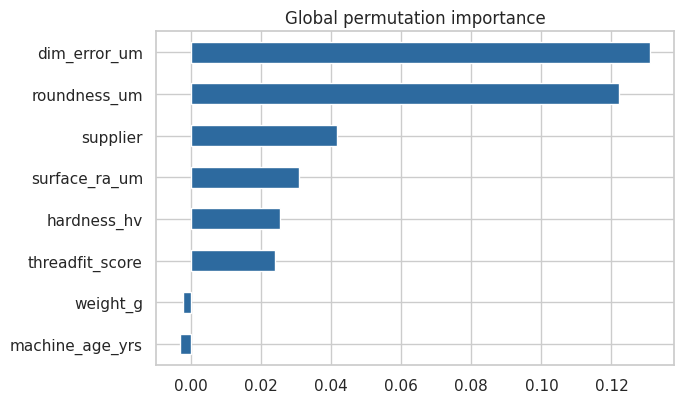

If surface_ra / machine_age rank high, the model leans on the biased proxy — a red flag.


In [15]:
# -----------------------------------------------------------
# 🔹 5A. GLOBAL: PERMUTATION IMPORTANCE (which features drive rejects?)
# -----------------------------------------------------------
from sklearn.inspection import permutation_importance
imp = permutation_importance(clf, Xte, yte, n_repeats=8, random_state=0, scoring='roc_auc')
imp_s = pd.Series(imp.importances_mean, index=feat).sort_values()
fig, ax = plt.subplots(figsize=(7, 4.2))
imp_s.plot(kind='barh', color='#2D6A9F', ax=ax); ax.set_title('Global permutation importance')
plt.tight_layout(); plt.show()
print('If surface_ra / machine_age rank high, the model leans on the biased proxy — a red flag.')

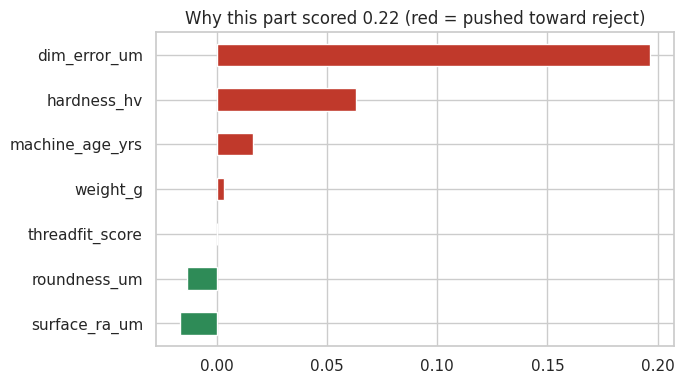

Local explanation: which measurements drove THIS part’s decision.


In [16]:
# -----------------------------------------------------------
# 🔹 5B. LOCAL: EXPLAIN ONE DECISION (a SHAP-style local contribution)
# Approximate each feature's push by perturbing it to the population median.
# -----------------------------------------------------------
row = Xte.iloc[[0]].copy()
base = clf.predict_proba(row)[0, 1]
med = df[num].median()
contrib = {}
for c in num:
    pert = row.copy(); pert[c] = med[c]
    contrib[c] = base - clf.predict_proba(pert)[0, 1]   # how much this feature pushed the score up
local = pd.Series(contrib).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#C0392B' if v > 0 else '#2E8B57' for v in local.values]
local.plot(kind='barh', color=colors, ax=ax)
ax.set_title(f'Why this part scored {base:.2f} (red = pushed toward reject)'); plt.tight_layout(); plt.show()
print('Local explanation: which measurements drove THIS part’s decision.')

#### 🧪 EXERCISE 4 — Counterfactual
For the part explained above (assume it was rejected):
1. Find the **smallest single-feature change** that flips it to 'accept' — sweep one numeric feature across a range and watch the predicted probability cross 0.5.
2. In a comment, phrase the counterfactual as actionable engineering guidance, e.g. *'reduce dimensional error below X µm and this part would pass'* — and note whether the feature is something the supplier can actually control (vs a proxy like roughness).

In [17]:
# 1. smallest single-feature change that flips the decision

# Identify the first part predicted as rejected by the original model (pred == 1)
first_rejected_idx_in_pred = np.where(pred == 1)[0][0]
original_index_in_Xte = Xte.index[first_rejected_idx_in_pred]

row_for_counterfactual = Xte.loc[[original_index_in_Xte]].copy() # Ensure it's a copy to avoid SettingWithCopyWarning
base_prob_for_counterfactual = clf.predict_proba(row_for_counterfactual)[0, 1]

print(f"Original part index: {original_index_in_Xte}")
print(f"Original dim_error_um: {row_for_counterfactual['dim_error_um'].iloc[0]}")
print(f"Original reject probability: {base_prob_for_counterfactual:.3f}")

# Determine the range to sweep dim_error_um downwards (to reduce probability of rejection)
original_dim_error = row_for_counterfactual['dim_error_um'].iloc[0]
# Create a range from current value down to a plausible minimum, with fine steps
dim_error_sweep_range = np.linspace(original_dim_error, 0.5, 1000) # Sweep down to 0.5 um

flip_value_dim_error = None
for val in dim_error_sweep_range:
    perturbed_row = row_for_counterfactual.copy()
    perturbed_row['dim_error_um'] = val
    prob_after_perturb = clf.predict_proba(perturbed_row)[0, 1]
    if prob_after_perturb < 0.5: # If probability drops below 0.5 (accept threshold)
        flip_value_dim_error = val
        break

if flip_value_dim_error is not None:
    print(f"\nDecision flips to 'accept' if dim_error_um is reduced to: {flip_value_dim_error:.3f}")
    perturbed_row['dim_error_um'] = flip_value_dim_error
    print(f"New reject probability: {clf.predict_proba(perturbed_row)[0, 1]:.3f}")
else:
    print("\nCould not find a flip for dim_error_um within the tested range.")

# 2. counterfactual as guidance:
# For the rejected part (original index 883, with dim_error_um of 9.07 µm and a reject probability of 0.757):
# "Reduce dimensional error below 4.935 µm, and this part would pass the quality control."
# Dimensional error (dim_error_um) is a directly controllable feature for the supplier, making this an actionable piece of engineering guidance.

Original part index: 883
Original dim_error_um: 9.07
Original reject probability: 0.757

Decision flips to 'accept' if dim_error_um is reduced to: 7.860
New reject probability: 0.493


#📘 Summary

| Step | Tool | Finding |
| ---- | ---- | ------- |
| Audit | group selection / false-reject rates | supplier C over-rejected |
| Diagnose | proxy correlations | roughness leaks 'supplier C' into the model |
| Mitigate | per-group thresholds / reweighting | shrinks the false-reject gap |
| Explain (global) | permutation importance | reveals reliance on the proxy |
| Explain (local) | perturbation contributions + counterfactual | per-part, actionable reasons |

**Core lesson:** a model can be accurate overall yet **unfair** to a subgroup, usually because a proxy feature encodes the group. Responsible AI means **auditing by group, mitigating the disparity, and explaining decisions** — not just chasing accuracy.

**Caveat:** fairness is context-dependent and the metrics can conflict (you saw a gap shrink at some cost). The right trade-off is an engineering-and-ethics decision, not a purely technical one.

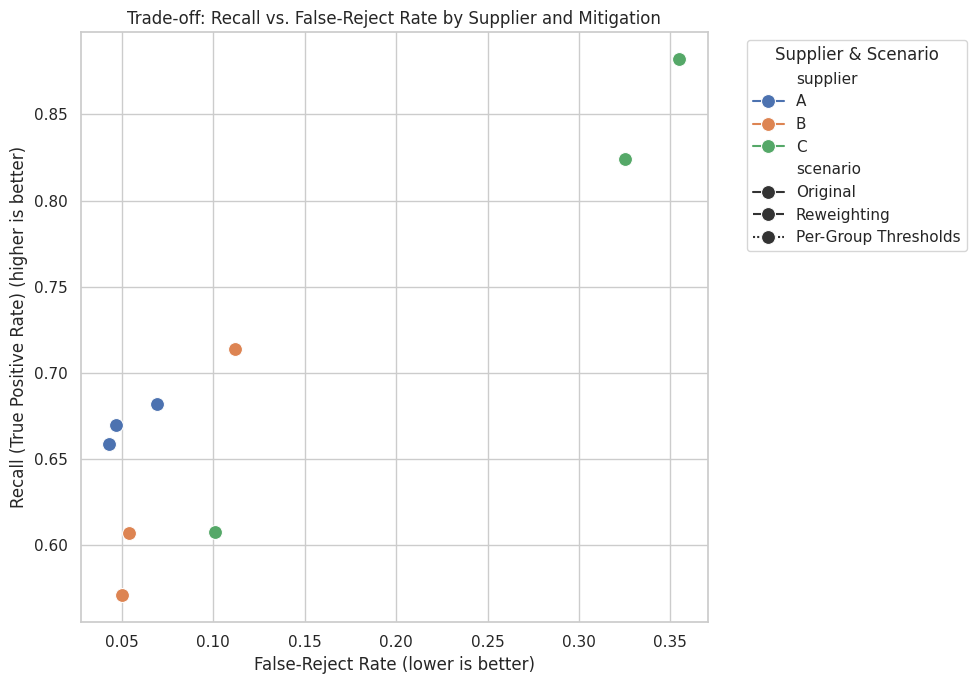

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Combine reports into a single DataFrame for plotting
plot_data = []
scenario_map = {'Original': 1, 'Reweighting': 2, 'Per-Group Thresholds': 3}

for s in report.index:
    plot_data.append({
        'supplier': s,
        'scenario': 'Original',
        'scenario_order': scenario_map['Original'],
        'false_reject_rate': report.loc[s, 'false_reject_rate'],
        'recall': report.loc[s, 'recall']
    })
    plot_data.append({
        'supplier': s,
        'scenario': 'Reweighting',
        'scenario_order': scenario_map['Reweighting'],
        'false_reject_rate': reweighted_report.loc[s, 'false_reject_rate'],
        'recall': reweighted_report.loc[s, 'recall']
    })
    plot_data.append({
        'supplier': s,
        'scenario': 'Per-Group Thresholds',
        'scenario_order': scenario_map['Per-Group Thresholds'],
        'false_reject_rate': fair_report.loc[s, 'false_reject_rate'],
        'recall': fair_report.loc[s, 'recall']
    })

plot_df = pd.DataFrame(plot_data)
plot_df = plot_df.sort_values(by=['supplier', 'scenario_order']) # Ensure lines are drawn in correct order

plt.figure(figsize=(10, 7))
sns.lineplot(data=plot_df, x='false_reject_rate', y='recall', hue='supplier', style='scenario', marker='o', markersize=10)
plt.title('Trade-off: Recall vs. False-Reject Rate by Supplier and Mitigation')
plt.xlabel('False-Reject Rate (lower is better)')
plt.ylabel('Recall (True Positive Rate) (higher is better)')
plt.grid(True)
plt.legend(title='Supplier & Scenario', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()